Script to see if I can calculate a closed-form solution for the variance necessary for a timeseries such that its filtered timeseries matches a target variance.

In [1]:
from methane_noise_forcing.noise import (
    calculate_two_timescale_ar1_params, 
    simulate_two_timescale_ar1, 
    calculate_white_noise_ar1_params, 
    simulate_white_noise_ar1
)
from methane_noise_forcing.core import FirnFilter
import matplotlib.pyplot as plt
import numpy as np

# generate firn filter + self-overlaps
Let the firn kernel at time k be denoted as $h_k$. Its self-overlap is defined as:
$$
c_\tau = \sum_{k=0}^{\infty} h_k \, h_{k+\tau}, \quad c_{-\tau} = c_\tau
$$

Since the firn kernel sums to 1, the self-overlap is equivalent to the autocorrelation of the firn kernel.

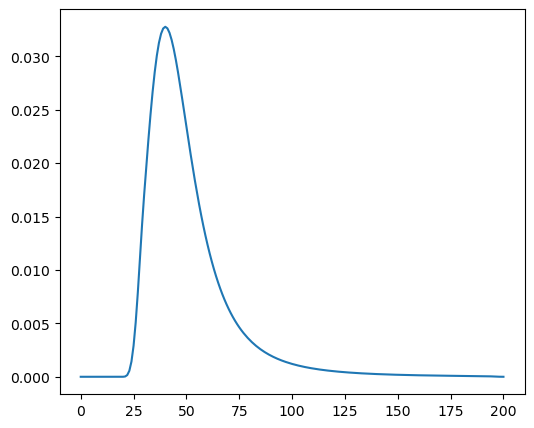

In [2]:
## create firn filter for closed porosity with log-logistic distribution
mode = 40 # years
fwhm = 26 # years
skew = 0.65
t_max = 200
dt = 1 # year
firn_filter = FirnFilter.fit_log_logistic(
    mode=mode, fwhm=fwhm, skew=skew, t_max=t_max, dt=dt
)

# plot the firn filter
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(
    np.arange(0, t_max + dt, dt),
    firn_filter.kernel,
)

In [3]:
## calculate self-overlaps
max_lag = 80

assert np.sum(firn_filter.kernel) == 1, "Firn filter kernel must sum to 1."

lags = np.arange(0, max_lag + 1, dt)  
c_taus = np.zeros_like(lags, dtype=float)
for i, tau in enumerate(lags):
    # calculate self-overlap at lag tau
    shift_idx = int(tau / dt) # index shift
    if shift_idx == 0:
        # Special case for lag=0: sum of squares
        c_tau = np.sum(firn_filter.kernel ** 2)
    else:
        c_tau = np.sum(firn_filter.kernel[:-shift_idx] * firn_filter.kernel[shift_idx:])
    c_taus[i] = c_tau

Text(0, 0.5, 'Self-overlap (autocorrelation)')

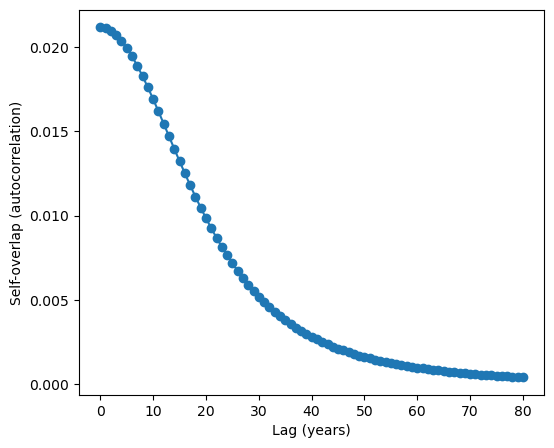

In [4]:
## plot self-overlaps
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(lags, c_taus, marker='o', linestyle='-')
ax.set_xlabel('Lag (years)')
ax.set_ylabel('Self-overlap (autocorrelation)')

# test variance filter on white noise + AR(1) forced by white noise
The underlying series $x$ variance $\sigma_x^2$ is related to the filtered series $y$ variance $\sigma_y^2$ by:
$$
\sigma_x^2 = \frac{\sigma_y^2}{c_0 + 2 \sum_{\tau=1}^{\infty} c_\tau \rho_x (\tau)}
$$

where $\rho_x(\tau)$ is the autocorrelation of the underlying series $x$ at lag $\tau$.

In [5]:
## generate white noise and AR(1) forcing associated with it
tau_ch4 = 10 # years
dt_years = 1 # year
var_ch4 = 225 # ppb^2
n_years = 1000 # years
n_ens = 10 # ensemble size
white_noise_ar1_params = calculate_white_noise_ar1_params(
    tau_years=tau_ch4, dt_years=dt_years, variance=var_ch4
)
ar1_ens, forcing_white_ens = simulate_white_noise_ar1(
    phi=white_noise_ar1_params.phi,
    sigma_eps=white_noise_ar1_params.sigma_eps,
    n_steps=n_years,
    n_ens=n_ens,
)

# smooth both ar1 and white noise forcing with firn filter
ar1_ens_smooth = np.zeros_like(ar1_ens)
forcing_white_ens_smooth = np.zeros_like(forcing_white_ens)
for i in range(n_ens):
    ar1_ens_smooth[i, :] = firn_filter.apply(ar1_ens[i, :])
    forcing_white_ens_smooth[i, :] = firn_filter.apply(forcing_white_ens[i, :])

AR(1) ensemble mean variance: 231.43 ± 11.24 ppb²
AR(1) smoothed ensemble mean variance: 67.68 ± 14.08 ppb²
White noise ensemble mean variance: 45.58 ± 2.04
White noise smoothed ensemble mean variance: 0.81 ± 0.12


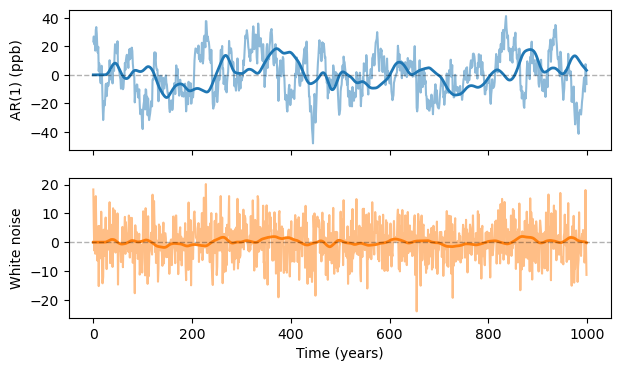

In [6]:
## plot ar1 and white noise forcing, original and smoothed
idx_ens = 0
fig, axs = plt.subplots(2, 1, figsize=(7, 4), sharex=True)
axs[0].plot(
    np.arange(0, n_years * dt_years, dt_years),
    ar1_ens[idx_ens, :], label='AR(1) forcing (original)', color='tab:blue', alpha=0.5
)
axs[0].plot(
    np.arange(0, n_years * dt_years, dt_years),
    ar1_ens_smooth[idx_ens, :], label='AR(1) forcing (smoothed)',
    color='tab:blue', linewidth=2
)
axs[0].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.3)
axs[0].set_ylabel('AR(1) (ppb)')

axs[1].plot(
    np.arange(0, n_years * dt_years, dt_years),
    forcing_white_ens[idx_ens, :], label='White noise forcing (original)',
    color='tab:orange', alpha=0.5
)
axs[1].plot(
    np.arange(0, n_years * dt_years, dt_years),
    forcing_white_ens_smooth[idx_ens, :], label='White noise forcing (smoothed)',
    color='tab:orange', linewidth=2
)
axs[1].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.3)
axs[1].set_xlabel('Time (years)')
axs[1].set_ylabel('White noise')

# print ensemble mean variance ± standard deviation for all timeseries
def calc_ensemble_variance_stats(ens_data):
    """Calculate mean and standard deviation of variance for ensemble data.
    Shape of ens_data is (n_ens, n_steps).
    """

    ens_var = np.var(ens_data, axis=1)
    ens_var_mean = np.mean(ens_var)
    ens_var_std = np.std(ens_var)

    return ens_var_mean, ens_var_std
ens_var_ar1_mean, ens_var_ar1_std = calc_ensemble_variance_stats(ar1_ens)
ens_var_white_mean, ens_var_white_std = calc_ensemble_variance_stats(forcing_white_ens)
ens_var_ar1_smooth_mean, ens_var_ar1_smooth_std = calc_ensemble_variance_stats(ar1_ens_smooth)
ens_var_white_smooth_mean, ens_var_white_smooth_std = calc_ensemble_variance_stats(forcing_white_ens_smooth)
print(f"AR(1) ensemble mean variance: {ens_var_ar1_mean:.2f} ± {ens_var_ar1_std:.2f} ppb²")
print(f"AR(1) smoothed ensemble mean variance: {ens_var_ar1_smooth_mean:.2f} ± {ens_var_ar1_smooth_std:.2f} ppb²")
print(f"White noise ensemble mean variance: {ens_var_white_mean:.2f} ± {ens_var_white_std:.2f}")
print(f"White noise smoothed ensemble mean variance: {ens_var_white_smooth_mean:.2f} ± {ens_var_white_smooth_std:.2f}")

## Compare filtered white noise variance to expected solution
For white noise $x$, the autocorrelation $\rho_x(\tau) = 0$ for all $\tau \neq 0$. Thus, the variance of the filtered white noise $y$ is:
$$
\sigma_y^2 = \sigma_x^2 \, c_0
$$

In [7]:
var_white_smooth_expected = ens_var_white_mean * c_taus[0]

print(f"White noise ensemble mean variance: {ens_var_white_mean:.2f} ± {ens_var_white_std:.2f}")
print(f"White noise smoothed ensemble mean variance: {ens_var_white_smooth_mean:.2f} ± {ens_var_white_smooth_std:.2f}")
print(f"Expected variance of smoothed white noise: {var_white_smooth_expected:.2f}")

White noise ensemble mean variance: 45.58 ± 2.04
White noise smoothed ensemble mean variance: 0.81 ± 0.12
Expected variance of smoothed white noise: 0.96


Pretty close! Looks good.

## Compare filtered AR(1) variance to expected solution
Let $\Phi = \exp(-1/\tau_0)$, where $\tau_0$ is the timescale of the AR(1) process. For AR(1) $x$ with autocorrelation $\rho_x(\tau) = \Phi^{|\tau|}$, the variance of the filtered AR(1) $y$ is:
$$
\sigma_y^2 = \sigma_x^2 \, \left( c_0 + 2 \sum_{\tau=1}^{\infty} c_\tau \Phi^{\tau} \right)
$$

In [8]:
Phi = np.exp(-1 / tau_ch4)

# calculate sum of self-overlaps weighted by AR(1) autocorrelation
# array of autocorrelation at lags 1, 2, ..., max_lag
rho_taus = np.array([Phi ** tau for tau in lags[1:]])
# sum of self-overlaps weighted by AR(1) autocorrelation
sum_c_taus_rho = np.sum(c_taus[1:] * rho_taus)

# calculate expected variance of smoothed AR(1)
var_ar1_smooth_expected = var_ch4 * (c_taus[0] + 2 * sum_c_taus_rho)

print(f"AR(1) ensemble mean variance: {ens_var_ar1_mean:.2f} ± {ens_var_ar1_std:.2f} ppb²")
print(f"AR(1) smoothed ensemble mean variance: {ens_var_ar1_smooth_mean:.2f} ± {ens_var_ar1_smooth_std:.2f} ppb²")
print(f"Expected variance of smoothed AR(1): {var_ar1_smooth_expected:.2f} ppb²")

AR(1) ensemble mean variance: 231.43 ± 11.24 ppb²
AR(1) smoothed ensemble mean variance: 67.68 ± 14.08 ppb²
Expected variance of smoothed AR(1): 75.13 ppb²


Again, pretty close! Looks good.

Below, we visualize the autocorrelation of the AR(1) autocorrelation and its multiplication with the firn kernel autocorrelation.

Text(0, 0.5, 'Self-overlap × AR(1) autocorrelation')

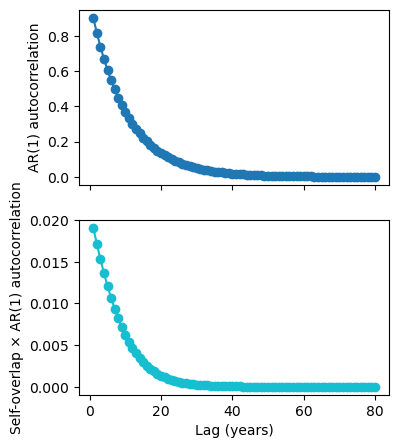

In [9]:
fig, axs = plt.subplots(2, 1, figsize=(4, 5), sharex=True)

axs[0].plot(lags[1:], rho_taus, marker='o', linestyle='-', color='tab:blue')
axs[0].set_ylabel('AR(1) autocorrelation')

axs[1].plot(lags[1:], c_taus[1:] * rho_taus, marker='o', linestyle='-', color='tab:cyan')
axs[1].set_xlabel('Lag (years)')
axs[1].set_ylabel('Self-overlap × AR(1) autocorrelation')

# test variance filter on two-timescale AR(1)

In [10]:
tau_ch4 = 10 # years
tau_forcing = 100 # years
dt_years = 1 # year
var_ch4 = 225 # ppb^2
n_years = 1000 # years
n_ens = 30 # ensemble size

ar1_two_timescale_ens, forcing_two_timescale_ens = simulate_two_timescale_ar1(
    tau_x=tau_ch4,
    tau_eta=tau_forcing,
    variance_x=var_ch4,
    dt=dt_years,
    n_steps=n_years,
    n_ens=n_ens,
)

# smooth ar1 with firn filter
ar1_two_timescale_ens_smooth = np.zeros_like(ar1_two_timescale_ens)
for i in range(n_ens):
    ar1_two_timescale_ens_smooth[i, :] = firn_filter.apply(ar1_two_timescale_ens[i, :])

Two-timescale AR(1) ensemble mean variance: 163.56 ± 76.82 ppb²
Two-timescale AR(1) smoothed ensemble mean variance: 133.61 ± 71.61 ppb²


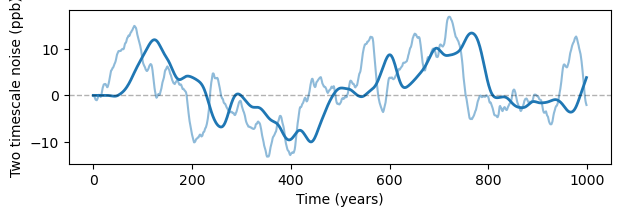

In [11]:
## plot downstream AR(1), original and smoothed
idx_ens = 0
fig, ax = plt.subplots(figsize=(7, 2))
ax.plot(
    np.arange(0, n_years * dt_years, dt_years),
    ar1_two_timescale_ens[idx_ens, :], label='AR(1) forcing (original)', color='tab:blue', alpha=0.5
)
ax.plot(
    np.arange(0, n_years * dt_years, dt_years),
    ar1_two_timescale_ens_smooth[idx_ens, :], label='AR(1) forcing (smoothed)',
    color='tab:blue', linewidth=2
)
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.3)
ax.set_xlabel('Time (years)')
ax.set_ylabel('Two timescale noise (ppb)')

# print ensemble mean variance ± standard deviation for two-timescale AR(1)
ens_var_ar1_two_timescale_mean, ens_var_ar1_two_timescale_std = calc_ensemble_variance_stats(ar1_two_timescale_ens)
ens_var_ar1_two_timescale_smooth_mean, ens_var_ar1_two_timescale_smooth_std = calc_ensemble_variance_stats(ar1_two_timescale_ens_smooth)
print(f"Two-timescale AR(1) ensemble mean variance: {ens_var_ar1_two_timescale_mean:.2f} ± {ens_var_ar1_two_timescale_std:.2f} ppb²")
print(f"Two-timescale AR(1) smoothed ensemble mean variance: {ens_var_ar1_two_timescale_smooth_mean:.2f} ± {ens_var_ar1_two_timescale_smooth_std:.2f} ppb²")

## Compare filtered two-timescale AR(1) variance to expected solution
For a system $x$ with autocorrelation $\Phi_1 = \exp(-1 / \tau_1)$ forced by another process $\eta$, which itself has autocorrelation $\Phi_0 = \exp(-1 / \tau_0)$ and is forced by white noise $\epsilon$, the autocovariance $\gamma(\tau)$ of the system $x$ at lag $\tau$ is given by:
$$
\gamma(\tau) = \frac{\sigma_\epsilon^2}{(\Phi_1 + \Phi_0)^2} \left[ \frac{\Phi_1^{\tau + 2}}{1 - \Phi_1^2} - \frac{\Phi_1 \, \Phi_0^{\tau + 1} + \Phi_0 \, \Phi_1^{\tau + 1}}{1 - \Phi_0 \, \Phi_1} + \frac{\Phi_0^{\tau + 2}}{1 - \Phi_0^2} \right]
$$
if $\Phi_0 \neq \Phi_1$.

Let $S(\tau)$ be the term in the brackets. The autocorrelation $\rho_x(\tau)$ of the system $x$ at lag $\tau$ is given by:
$$
\rho_x(\tau) = \frac{S(\tau)}{S(0)}
$$

In the special case where $\tau_0 = \tau_1$, the autocorrelation simplifies to:
$$
\rho_x(\tau) = \sigma_{\epsilon}^2 \Phi^{\tau} \frac{\tau + 1 + (1 - \tau) \Phi^2}{(1 - \Phi^2)^3}
$$

Therefore, let $S(\tau)$ be defined as:
$$
S(\tau) = \Phi^\tau \left[ \tau + 1 + (1 - \tau) \Phi^2 \right]
$$

In [12]:
## define functions to calculate S(τ) and ρ_x(τ)
def calculate_term_1_3(tau, phi):
    """Calculate the first and third term in the S(τ) formula."""
    return (phi ** (tau + 2)) / (1 - phi ** 2)
def calculate_term_2(tau, phi_0, phi_1):
    """Calculate the second term in the S(τ) formula."""
    return (phi_1 * phi_0 ** (tau + 1) + phi_0 * phi_1 ** (tau + 1)) / (1 - phi_0 * phi_1)
def calculate_S(tau, phi_0, phi_1):
    """Calculate the S(τ) term for the two-timescale AR(1) process."""
    if phi_0 == phi_1: # if identical, use other calculation of S(τ)
        return phi_0**tau * (tau + 1 + (1 - tau) * phi_0**2)
    else:
        term_1 = calculate_term_1_3(tau, phi_1)
        term_2 = calculate_term_2(tau, phi_0, phi_1)
        term_3 = calculate_term_1_3(tau, phi_0)
        return term_1 - term_2 + term_3

def calculate_rho_x(tau, phi_0, phi_1):
    """Calculate the autocorrelation ρ_x(τ) for the two-timescale AR(1) process."""
    S_tau = calculate_S(tau, phi_0, phi_1)
    S_0 = calculate_S(0, phi_0, phi_1)
    return S_tau / S_0

In [13]:
## calculate expected + empirical autocorrelation for two-timescale AR(1)
phi_0 = np.exp(-1 / tau_forcing)
phi_1 = np.exp(-1 / tau_ch4)
phi_x_taus_expected = np.zeros_like(lags, dtype=float)
phi_x_taus_empirical = np.zeros_like(lags, dtype=float)

for i, tau in enumerate(lags):
    if tau == 0:
        # zero-lag is always perfect correlation
        phi_x_taus_expected[i]  = 1.0
        phi_x_taus_empirical[i] = 1.0
    else:
        # theoretical
        phi_x_taus_expected[i] = calculate_rho_x(tau, phi_0, phi_1)
        
        # empirical: compute corr for *each* ensemble member, then average
        corrs = [
            np.corrcoef(ens[:-tau], ens[tau:])[0, 1]
            for ens in ar1_two_timescale_ens
        ]
        phi_x_taus_empirical[i] = np.mean(corrs)

In [14]:
## multiply expected autocorrelation by self-overlap
sum_c_taus_rho_x = np.sum(c_taus[1:] * phi_x_taus_expected[1:])

# calculate expected variance of two-timescale smoothed AR(1)
var_ar1_x_smooth_expected = var_ch4 * (c_taus[0] + 2 * sum_c_taus_rho_x)

print(f"Two-timescale AR(1) ensemble mean variance: {ens_var_ar1_two_timescale_mean:.2f} ± {ens_var_ar1_two_timescale_std:.2f} ppb²")
print(f"Two-timescale AR(1) smoothed ensemble mean variance: {ens_var_ar1_two_timescale_smooth_mean:.2f} ± {ens_var_ar1_two_timescale_smooth_std:.2f} ppb²")
print(f"Expected variance of smoothed two-timescale AR(1): {var_ar1_x_smooth_expected:.2f} ppb²")

Two-timescale AR(1) ensemble mean variance: 163.56 ± 76.82 ppb²
Two-timescale AR(1) smoothed ensemble mean variance: 133.61 ± 71.61 ppb²
Expected variance of smoothed two-timescale AR(1): 198.95 ppb²


Text(0, 0.5, 'Self-overlap × Autocorrelation')

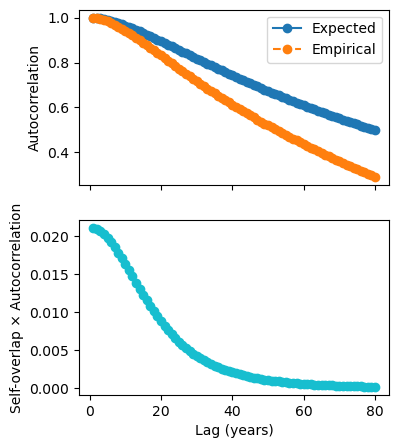

In [15]:
fig, axs = plt.subplots(2, 1, figsize=(4, 5), sharex=True)

axs[0].plot(lags[1:], phi_x_taus_expected[1:], label='Expected', marker='o', linestyle='-', color='tab:blue')
axs[0].plot(lags[1:], phi_x_taus_empirical[1:], label='Empirical', marker='o', linestyle='--', color='tab:orange')
axs[0].set_ylabel('Autocorrelation')
axs[0].legend()

axs[1].plot(lags[1:], c_taus[1:] * phi_x_taus_expected[1:], label='Expected × Self-overlap', marker='o', linestyle='-', color='tab:cyan')
axs[1].set_xlabel('Lag (years)')
axs[1].set_ylabel('Self-overlap × Autocorrelation')

Behaves as expected! Larger timescales require longer integration times or larger ensemble sizes to converge to the expected solution, which is expected since they have fewer independent degrees of freedom.

Effective level-off of the autocorrelation of the firn kernel is 80 years, so I will sweep across a variety of timescales (0.1 to 100 years) to see how the variance behaves.

In [16]:
# sweep across forcing timescales to calculate variance of un-smoothed signal needed to reach variance of smoothed signal
tau_ch4 = 10 # years
target_smoothed_variance = 10**2 # ppb²
tau_forcings = np.array([0.1, 0.5, 1, 5, 10, 50, 100]) # years
phi_1 = np.exp(-1 / tau_ch4)
def calculate_variance_scaling_factor(tau_forcing, lags, c_taus):
    """Calculate the ratio of the smoothed variance to the un-smoothed variance."""
    phi_0 = np.exp(-1 / tau_forcing)
    sum_c_taus_rho_x = np.sum(c_taus[1:] * calculate_rho_x(lags, phi_0, phi_1)[1:])
    return (c_taus[0] + 2 * sum_c_taus_rho_x)

variance_scaling_factors = {}
un_smoothed_variances = {}

for tau_forcing in tau_forcings:
    scaling_factor = calculate_variance_scaling_factor(tau_forcing, lags, c_taus)
    un_smoothed_variance = target_smoothed_variance / scaling_factor
    variance_scaling_factors[tau_forcing] = scaling_factor
    un_smoothed_variances[tau_forcing] = un_smoothed_variance
    print(f"Forcing timescale {tau_forcing} years: un-smoothed variance needed to reach {target_smoothed_variance} ppb² is {un_smoothed_variance:.2f} ppb²")

Forcing timescale 0.1 years: un-smoothed variance needed to reach 100 ppb² is 299.47 ppb²
Forcing timescale 0.5 years: un-smoothed variance needed to reach 100 ppb² is 291.87 ppb²
Forcing timescale 1.0 years: un-smoothed variance needed to reach 100 ppb² is 277.17 ppb²
Forcing timescale 5.0 years: un-smoothed variance needed to reach 100 ppb² is 211.82 ppb²
Forcing timescale 10.0 years: un-smoothed variance needed to reach 100 ppb² is 176.70 ppb²
Forcing timescale 50.0 years: un-smoothed variance needed to reach 100 ppb² is 122.91 ppb²
Forcing timescale 100.0 years: un-smoothed variance needed to reach 100 ppb² is 113.09 ppb²


In [17]:
## for good measure, also calculate needed variance of the AR(1) forcing to reach the same smoothed variance
def calculate_forcing_variance(variance_ch4, tau_ch4, tau_forcing): # from noise_integration.ipynb
    numerator = 2*(tau_ch4 + tau_forcing)
    demoninator = tau_ch4**2 * tau_forcing
    return variance_ch4 * (numerator / demoninator)

forcing_variances = {}
for tau_forcing, un_smoothed_variance in un_smoothed_variances.items():
    forcing_variances[tau_forcing] = calculate_forcing_variance(un_smoothed_variance, tau_ch4, tau_forcing)

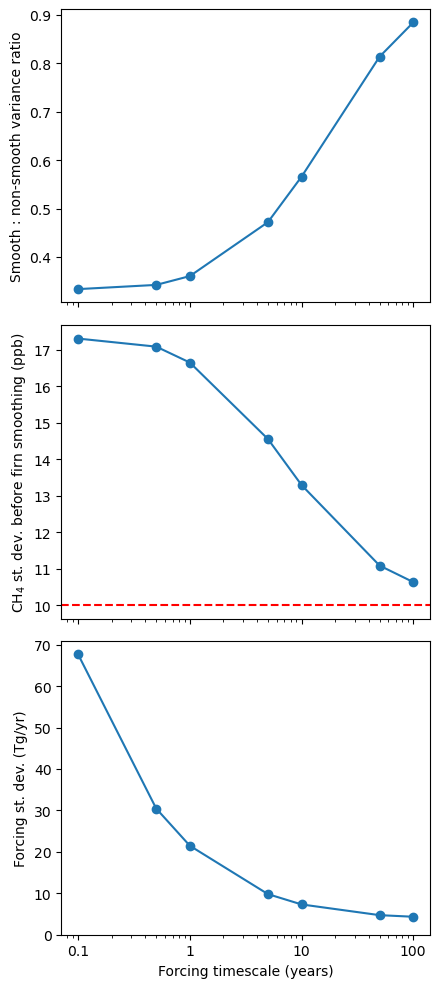

In [18]:
## plot scaling factors and un-smoothed standard deviations
fig, axs = plt.subplots(3, 1, figsize=(4.5, 10), sharex=True)

# scaling factors
axs[0].plot(tau_forcings, list(variance_scaling_factors.values()), marker='o', linestyle='-')
axs[0].set_ylabel('Smooth : non-smooth variance ratio')

# standard deviation of un-smoothed signal (ch4)
un_smoothed_stds = np.sqrt(list(un_smoothed_variances.values()))
axs[1].plot(tau_forcings, un_smoothed_stds, marker='o', linestyle='-')
axs[1].axhline(np.sqrt(target_smoothed_variance), color='red', linestyle='--', label='Target smoothed std')
axs[1].set_ylabel('CH$_4$ st. dev. before firn smoothing (ppb)')

# standard deviation of forcings (Tg/yr)
forcing_stds = np.sqrt(list(forcing_variances.values())) * 2.75 # convert ppb/yr to Tg/yr
axs[2].plot(tau_forcings, forcing_stds, marker='o', linestyle='-')
axs[2].set_ylabel('Forcing st. dev. (Tg/yr)')
axs[2].set_xlabel('Forcing timescale (years)')
ticks = [0.1, 1, 10, 100]
axs[2].set_xscale('log')
axs[2].set_xticks(ticks)
axs[2].set_xticklabels(ticks)
axs[2].set_ylim(0, None)

plt.tight_layout()

Above plots support my suspicion that the variance needed in the upstream processes to reach the same smoothed variance increases as the forcing timescale decreases, but they all seem to level off at close to 10 years (when the forcing timescale is equivalent to the methane lifetime). There is a leveling off at the upper bound of the forcing timescale for the firn process, but the forcing required to reach the same un-smoothed variance continues to increase. So the change in variance required overall looks like a 1/x function.